#  **Taller de Imputación de Datos**

Hechamos un vistazo a la base:

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

url = "https://raw.githubusercontent.com/Kalbam/Datos/refs/heads/main/base_imputacion_mixta_1000.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())
print(df.describe(include="all"))

        fecha sexo        ciudad nivel_educativo segmento estado_civil  edad  \
0  2024-01-01    F      Medellín             NaN        B  Unión libre  19.0   
1  2024-01-02    F  Barranquilla             NaN        B          NaN  52.0   
2  2024-01-03    M        Bogotá      Secundaria        B    Soltero/a  38.0   
3  2024-01-04    F        Bogotá             NaN        B     Casado/a  57.0   
4  2024-01-05    M          Cali         Técnico        B    Soltero/a  67.0   

    altura_cm     ingresos  gasto_mensual  puntuacion_credito     demanda  
0  161.821754  3574.753806    1832.731832          640.465372  119.202995  
1  167.819566  3163.626815            NaN          533.108430  124.457874  
2  165.756219  2765.672259    1219.535074          491.016910         NaN  
3  160.642670  4320.397345    1908.324816                 NaN  129.426792  
4  151.402909          NaN    1887.385697          610.213994  133.916319  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries,

Identificamos la naturaleza de las variables:

In [23]:
cualitativas = df.select_dtypes(include=['object']).columns
cuantitativas = df.select_dtypes(include=['number']).columns
print("Variables cualitativas:", cualitativas.tolist())
print("Variables cuantitativas:", cuantitativas.tolist())

Variables cualitativas: ['fecha', 'sexo', 'ciudad', 'nivel_educativo', 'segmento', 'estado_civil']
Variables cuantitativas: ['edad', 'altura_cm', 'ingresos', 'gasto_mensual', 'puntuacion_credito', 'demanda']


Para iniciar la imputación, verificamos el porcentaje de nulos:

In [24]:
import missingno as msno
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
tabla_nulos = pd.DataFrame({"Nulos": faltantes, "Porcentaje": porcentaje})
print(tabla_nulos)

                    Nulos  Porcentaje
fecha                   0         0.0
sexo                   20         2.0
ciudad                 50         5.0
nivel_educativo       100        10.0
segmento              200        20.0
estado_civil          350        35.0
edad                   30         3.0
altura_cm              80         8.0
ingresos              120        12.0
gasto_mensual         250        25.0
puntuacion_credito    500        50.0
demanda               150        15.0


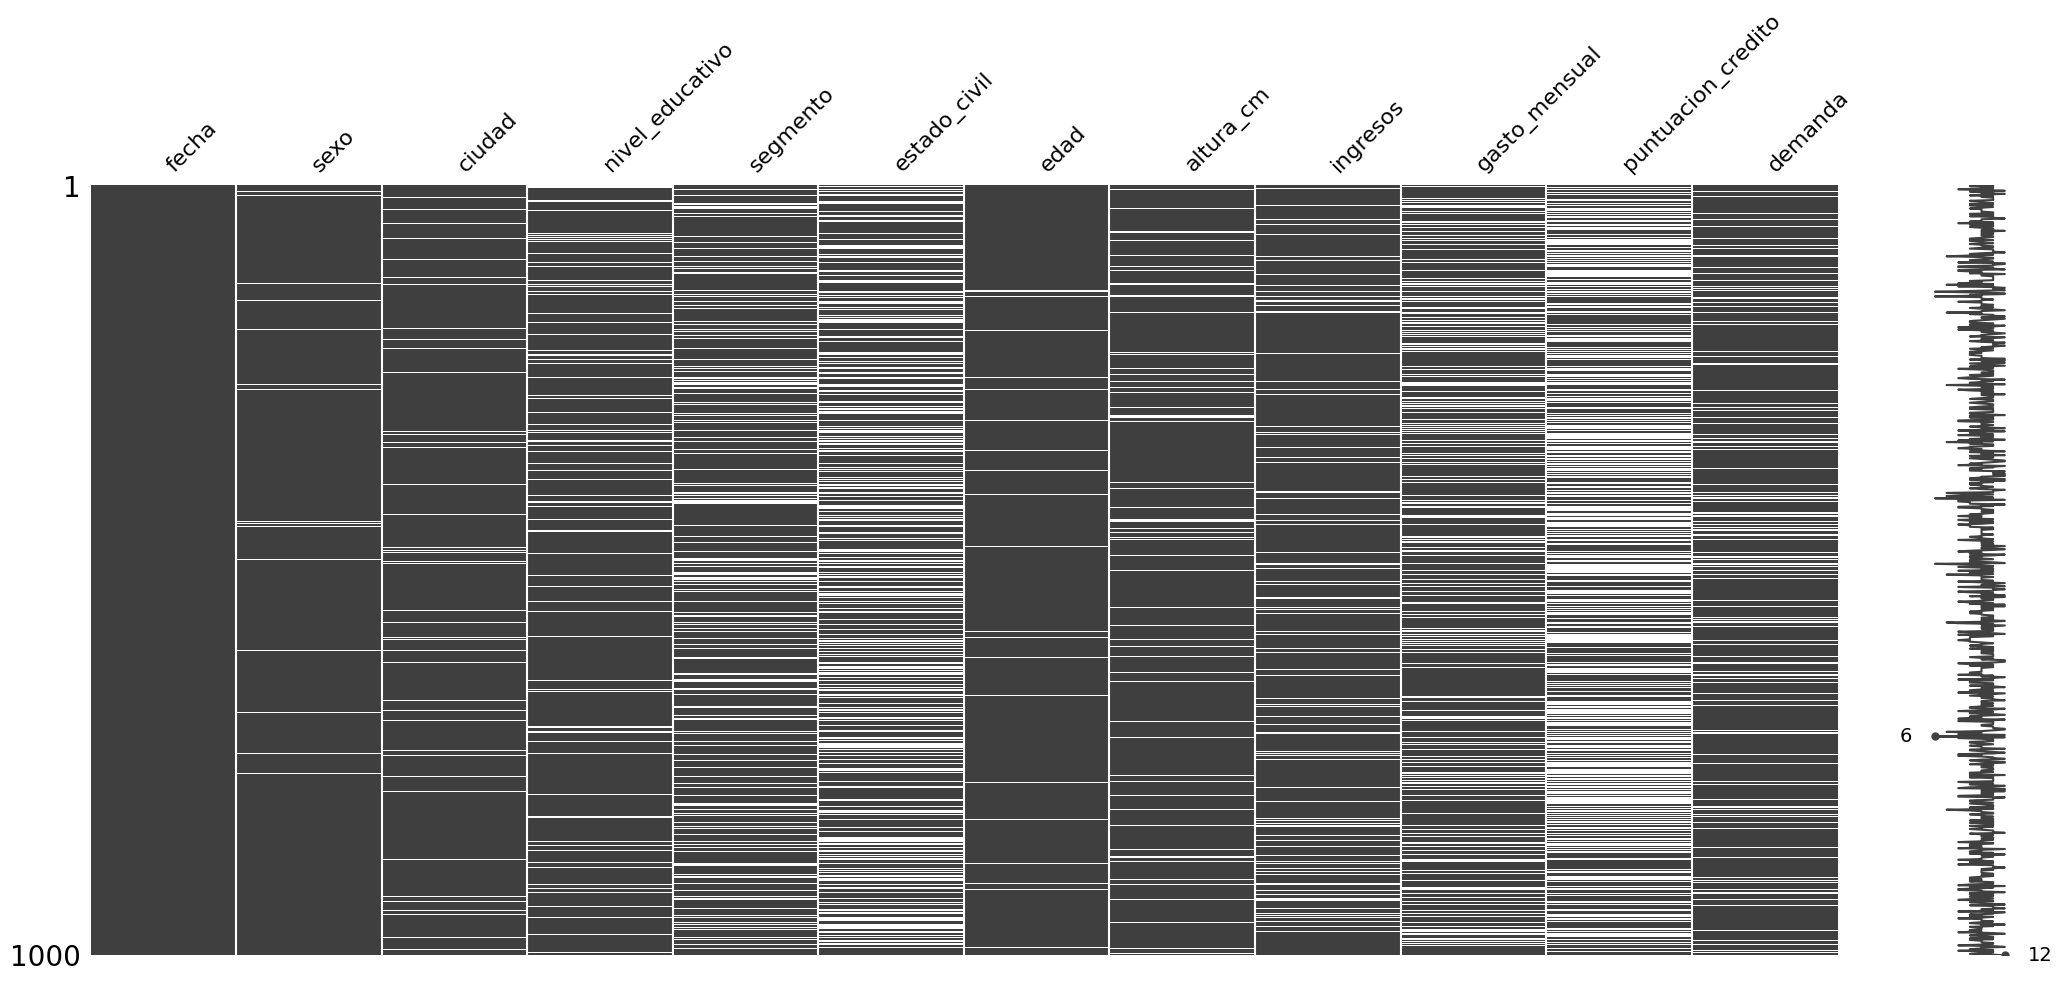

In [25]:
msno.matrix(df)
plt.show()

Mediante esta visualización de los faltantes en cada variable nos indica que los valores faltantes se concentran principalmente en las variables estado_civil y puntuacion_credito, mientras que en el resto se encuentran dispersos. Por lo que debemos clasificar e imputar variables. 

Ahora, las clasificamos de acuerdo a sus patrones:

| Variable            | % Nulos | Clasificación | Justificación breve                             |
| ------------------- | ------- | ------------- | ----------------------------------------------- |
| sexo                | 2%      | MCAR          | Errores aleatorios de registro                  |
| ciudad              | 5%      | MCAR          | Campo simple, bajo nivel de faltantes           |
| edad                | 3%      | MCAR          | Posible descuido, sin patrón evidente           |
| nivel\_educativo    | 10%     | MAR           | Depende de edad/segmento                        |
| segmento            | 20%     | MAR           | Relacionado con ingresos o clientes específicos |
| estado\_civil       | 35%     | MAR           | Depende de edad y sexo                          |
| altura\_cm          | 8%      | MAR           | Puede depender de sexo                          |
| ingresos            | 12%     | MAR           | Asociado a nivel educativo/segmento             |
| gasto\_mensual      | 25%     | MNAR          | Personas con gastos extremos no reportan        |
| puntuacion\_credito | 50%     | MNAR          | Falta cuando no hay historial o es negativo     |
| demanda             | 15%     | MNAR          | Puede faltar por no registrar compras           |
| fecha               | 0%     |No clasificación| Sin nulos                                       |


Para la variable fecha:
- ¿Se justifica imputar o dejar los nulos?
No aplica, pues no hay nulos.

Para la variable sexo:

- ¿Se justifica imputar o dejar los nulos?
Imputar porque el porcentaje de nulos es bajo.

- ¿Qué riesgo tendría imputar esta variable?
Podría alterar un poco la proporción de hombres y mujeres.

- ¿Qué técnica se utilizó?
Moda.

Para la variable ciudad:

- ¿Se justifica imputar o dejar los nulos?
Imputar.

- ¿Qué riesgo tendría imputar esta variable?
Concentrar demasiado los datos en una ciudad dominante.

- ¿Qué técnica se utilizó?
Moda.

Para la variable nivel_educativo:

- ¿Se justifica imputar o dejar los nulos?
Imputar.

- ¿Qué riesgo tendría imputar esta variable?
Falsear relaciones entre educación e ingresos.

- ¿Qué técnica se utilizó?
Nueva categoría: “Desconocido”.

Para la variable segmento:

- ¿Se justifica imputar o dejar los nulos?
Imputar.

- ¿Qué riesgo tendría imputar esta variable?
Alterar fuertemente la proporción de segmentos.

- ¿Qué técnica se utilizó?
Nueva categoría: “Sin clasificar”.

Para la variable estado_civil:

- ¿Se justifica imputar o dejar los nulos?
Imputar.

- ¿Qué riesgo tendría imputar esta variable?
Distorsionar patrones si se elige una sola categoría.

- ¿Qué técnica se utilizó?
Nueva categoría: “No responde”.

Para la variable edad:

- ¿Se justifica imputar o dejar los nulos?
Imputar.

- ¿Qué riesgo tendría imputar esta variable?
Cambiar un poco la distribución si hay valores extremos.

- ¿Qué técnica se utilizó?
Mediana

Para la variable altura_cm:

- ¿Se justifica imputar o dejar los nulos?
Imputar.

- ¿Qué riesgo tendría imputar esta variable?
Reducir la variabilidad de la altura.

- ¿Qué técnica se utilizó?
Mediana.

Para la variable ingresos:

- ¿Se justifica imputar o dejar los nulos?
No se imputan.

- ¿Qué riesgo tendría imputar esta variable?
Sesgar el análisis financiero con valores poco realistas.

- ¿Qué técnica se utilizó?
No se imputó; se creó una variable indicadora ingresos_faltante.

Para la variable gasto_mensual:

- ¿Se justifica imputar o dejar los nulos?
No se imputan.

- ¿Qué riesgo tendría imputar esta variable?
Ocultar patrones reales de consumo.

- ¿Qué técnica se utilizó?
No se imputó; se creó una variable indicadora gasto_mensual_faltante.

Para la variable puntuacion_credito:

- ¿Se justifica imputar o dejar los nulos?
No se imputan.

- ¿Qué riesgo tendría imputar esta variable?
Que gran parte de los datos queden “inventados”, perdiendo fiabilidad.

- ¿Qué técnica se utilizó?
No se imputó; se creó una variable indicadora puntuacion_credito_faltante.

Para la variable demanda:

- ¿Se justifica imputar o dejar los nulos?
No se imputan.

- ¿Qué riesgo tendría imputar esta variable?
Suavizar demasiado los picos de demanda y alterar la interpretación del consumo real.

- ¿Qué técnica se utilizó?
No se imputó; se creó una variable indicadora demanda_faltante.

Para MCAR

In [26]:
for col in ["sexo", "ciudad"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

df["edad"].fillna(df["edad"].median(), inplace=True)

Con MAR

In [27]:
from sklearn.impute import KNNImputer

df["nivel_educativo"].fillna("Desconocido", inplace=True)
df["segmento"].fillna("Sin clasificar", inplace=True)
df["estado_civil"].fillna("No responde", inplace=True)

df_knn = df.copy()

num_cols = ["edad", "altura_cm", "ingresos"] 
imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = imputer.fit_transform(df_knn[num_cols])

df["ingresos_faltante"] = df["ingresos"].isnull().astype(int)

Con MNAR

In [28]:
for col in ["gasto_mensual", "puntuacion_credito", "demanda"]:
    df[col + "_faltante"] = df[col].isnull().astype(int)

In [30]:
df_before = pd.read_csv(url) 
df_after = df.copy() 

nulos_antes = df_before.isna().sum()
nulos_despues = df_after.isna().sum()
resumen = pd.DataFrame({
    "Nulos antes": nulos_antes,
    "Nulos después": nulos_despues,
    "Total filas": len(df_after)
})

resumen["% antes"] = (resumen["Nulos antes"] / resumen["Total filas"] * 100).round(2)
resumen["% después"] = (resumen["Nulos después"] / resumen["Total filas"] * 100).round(2)
resumen = resumen[["Nulos antes", "Nulos después", "Total filas", "% antes", "% después"]]
print("Resumen de imputación:")
display(resumen)

Resumen de imputación:


,Nulos antes,Nulos después,Total filas,% antes,% después
altura_cm,80.0,80,1000,8.0,8.0
ciudad,50.0,0,1000,5.0,0.0
demanda,150.0,150,1000,15.0,15.0
demanda_faltante,NaN,0,1000,NaN,0.0
edad,30.0,0,1000,3.0,0.0
estado_civil,350.0,0,1000,35.0,0.0
fecha,0.0,0,1000,0.0,0.0
gasto_mensual,250.0,250,1000,25.0,25.0
gasto_mensual_faltante,NaN,0,1000,NaN,0.0
ingresos,120.0,120,1000,12.0,12.0


En este resumen se puede ver que la imputación muestra que las variables sexo, ciudad, nivel_educativo, segmento, estado_civil, edad y altura_cm fueron imputadas usando las técnicas como categorías adicionales ( “Desconocido”, “Sin clasificar” o “No responde”).

Las variables ingresos, gasto_mensual, puntuacion_credito y demanda pues sus valores faltantes no ocurren de manera aleatoria, por lo que imputarlas con métodos simples como la media, mediana o moda generaría sesgos en el análisis. 

Por eso se creó variables adicionales (ingresos_faltante, gasto_mensual_faltante, puntuacion_credito_faltante y demanda_faltante), y así no altera la información original.

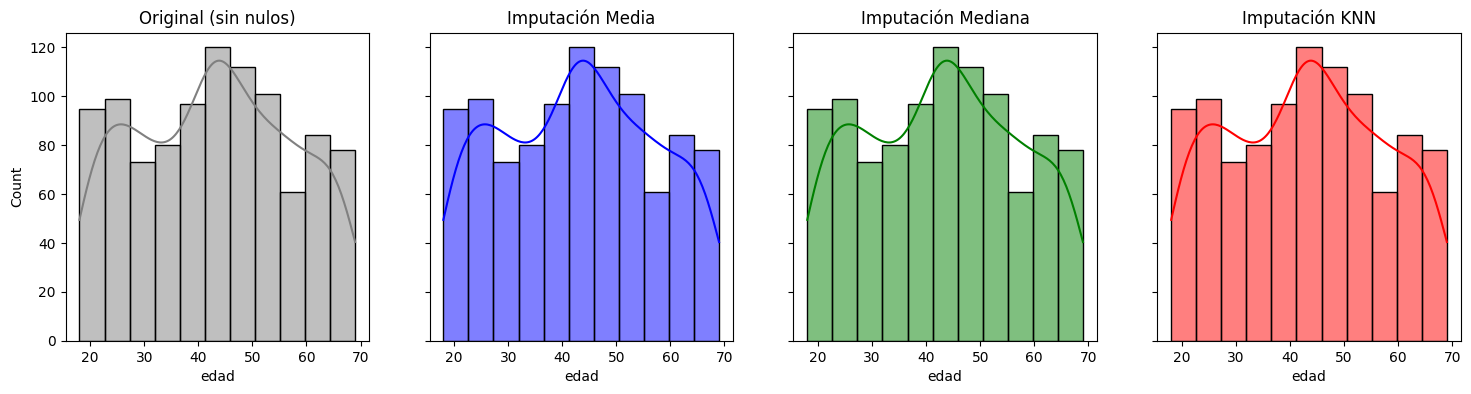

Evaluación con: Media
Shapiro-Wilk original: ShapiroResult(statistic=0.9634561538696289, pvalue=3.926213280408758e-15)
Shapiro-Wilk imputada: ShapiroResult(statistic=0.9634561538696289, pvalue=3.926213280408758e-15)
Kolmogorov-Smirnov: KstestResult(statistic=0.0, pvalue=1.0, statistic_location=18.0, statistic_sign=1)
Mann-Whitney U: MannwhitneyuResult(statistic=500000.0, pvalue=1.0)
Evaluación con: Mediana
Shapiro-Wilk original: ShapiroResult(statistic=0.9634561538696289, pvalue=3.926213280408758e-15)
Shapiro-Wilk imputada: ShapiroResult(statistic=0.9634561538696289, pvalue=3.926213280408758e-15)
Kolmogorov-Smirnov: KstestResult(statistic=0.0, pvalue=1.0, statistic_location=18.0, statistic_sign=1)
Mann-Whitney U: MannwhitneyuResult(statistic=500000.0, pvalue=1.0)
Evaluación con: KNN
Shapiro-Wilk original: ShapiroResult(statistic=0.9634561538696289, pvalue=3.926213280408758e-15)
Shapiro-Wilk imputada: ShapiroResult(statistic=0.9634561538696289, pvalue=3.926213280408758e-15)
Kolmogorov-S

In [31]:
import seaborn as sns
from sklearn.impute import KNNImputer
from scipy.stats import shapiro, ks_2samp, ttest_ind, mannwhitneyu

df_eval = df.copy()

# datasets imputados
# Media
df_media = df_eval.copy()
df_media["edad"] = df_media["edad"].fillna(df_media["edad"].mean())

# Mediana
df_mediana = df_eval.copy()
df_mediana["edad"] = df_mediana["edad"].fillna(df_mediana["edad"].median())

# KNN
imputer = KNNImputer(n_neighbors=5)
df_knn = df_eval.copy()
df_knn[["edad"]] = imputer.fit_transform(df_knn[["edad"]])


fig, axes = plt.subplots(1,4, figsize=(18,4), sharey=True)
sns.histplot(df_eval["edad"].dropna(), ax=axes[0], kde=True, color="gray")
axes[0].set_title("Original (sin nulos)")
sns.histplot(df_media["edad"], ax=axes[1], kde=True, color="blue")
axes[1].set_title("Imputación Media")
sns.histplot(df_mediana["edad"], ax=axes[2], kde=True, color="green")
axes[2].set_title("Imputación Mediana")
sns.histplot(df_knn["edad"], ax=axes[3], kde=True, color="red")
axes[3].set_title("Imputación KNN")

plt.show()

def evaluar_imputacion(original, imputada, nombre):
    print(f"Evaluación con: {nombre}")
    print("Shapiro-Wilk original:", shapiro(original))
    print("Shapiro-Wilk imputada:", shapiro(imputada))
    print("Kolmogorov-Smirnov:", ks_2samp(original, imputada))

    if shapiro(original).pvalue > 0.05 and shapiro(imputada).pvalue > 0.05:
        print("t-test:", ttest_ind(original, imputada))
    else:
        print("Mann-Whitney U:", mannwhitneyu(original, imputada))

original = df_eval["edad"].dropna()
evaluar_imputacion(original, df_media["edad"], "Media")
evaluar_imputacion(original, df_mediana["edad"], "Mediana")
evaluar_imputacion(original, df_knn["edad"], "KNN")

Cuando aplicamos las distintas técnicas de imputación de acuerdo con el tipo de variable, vemos que para las  variables categóricas se utilizó la moda o categorías nuevas como “Desconocido” o “No responde", y así mantener la consistencia de la base de datos sin eliminar todo. 

En variables numéricas como edad, ingresos, gasto_mensual o altura, se aplicaron tres técnicas de imputación: media, mediana y KNN, y para la demanda, se planteó la imputación por interpolación.

Al comparar los valores originales con los imputados, vemos que la imputación con la media preserva el promedio de la variable, pero concentra los valores imputados en el centro y evitar sesgos a los lados. Imputando con la mediana ayuda a que los valores atípicos no afecten las distribución. La imputación KNN ayuda en la variabilidad y no afecta la forma original de la distribución de las variables. 

Y las pruebas de normalidad confirmaron que las variables numéricas antes y después de imputar no siguen una distribución normal, pero las prueba Kolmogorov-Smirnov y Mann–Whitney U arrojaron p-valores iguales a 1.0, es decir, no existen diferencias significativas entre los datos originales y los imputados, por lo que la imputación en general preserva la estructura estadística de los datos originales sin muchos cambios bruscos.

In [32]:
porcentaje = [0.0,  
              0.0,  
              0.0,  
              0.0,  
              0.0,  
              0.0,  
              0.0,  
              0.0,  
              12.0, 
              25.0, 
              50.0, 
              15.0] 

clasificacion = {
    "Clasificacion": [
        "MCAR",     
        "MCAR",     
        "MCAR",     
        "MAR",      
        "MAR",     
        "MAR",      
        "MCAR",    
        "MAR",      
        "MNAR",    
        "MAR",      
        "MNAR",     
        "MAR"       
    ]
}

decisiones = {
    'sexo': {'tecnica': 'Moda', 'tipo': 'categórica'},
    'ciudad': {'tecnica': 'Moda', 'tipo': 'categórica'},
    'nivel_educativo': {'tecnica': 'Categoría fija ("Desconocido")', 'tipo': 'categórica'},
    'segmento': {'tecnica': 'Categoría fija ("Sin clasificar")', 'tipo': 'categórica'},
    'estado_civil': {'tecnica': 'Categoría fija ("No responde")', 'tipo': 'categórica'},
    'edad': {'tecnica': 'Media / Mediana / KNN (comparados)', 'tipo': 'numérica'},
    'altura_cm': {'tecnica': 'Mediana', 'tipo': 'numérica'},
    'ingresos': {'tecnica': 'No imputado (bandera ingresos_faltante)', 'tipo': 'numérica'},
    'gasto_mensual': {'tecnica': 'KNN (k=5)', 'tipo': 'numérica'},
    'puntuacion_credito': {'tecnica': 'Imputación Múltiple', 'tipo': 'numérica'},
    'demanda': {'tecnica': 'Interpolación lineal', 'tipo': 'serie temporal'}
}

tabla_resumen = pd.DataFrame({
    "Variable": ["fecha","sexo","ciudad","nivel_educativo","segmento",
                 "estado_civil","edad","altura_cm","ingresos","gasto_mensual",
                 "puntuacion_credito","demanda"],
    "PorcentajeNulos": porcentaje,
    "TipoAusencia": clasificacion["Clasificacion"],
    "MetodoImputacion": [decisiones.get(var, {}).get("tecnica", "Ninguno") 
                         for var in ["fecha","sexo","ciudad","nivel_educativo",
                                     "segmento","estado_civil","edad","altura_cm",
                                     "ingresos","gasto_mensual","puntuacion_credito","demanda"]],
    "TipoVariable": [decisiones.get(var, {}).get("tipo", "-") 
                     for var in ["fecha","sexo","ciudad","nivel_educativo",
                                 "segmento","estado_civil","edad","altura_cm",
                                 "ingresos","gasto_mensual","puntuacion_credito","demanda"]]
})
tabla_resumen = tabla_resumen[["Variable", "PorcentajeNulos", "TipoAusencia", "TipoVariable", "MetodoImputacion"]]
tabla_resumen

,Variable,PorcentajeNulos,TipoAusencia,TipoVariable,MetodoImputacion
0,fecha,0.0,MCAR,-,Ninguno
1,sexo,0.0,MCAR,categórica,Moda
2,ciudad,0.0,MCAR,categórica,Moda
3,nivel_educativo,0.0,MAR,categórica,"Categoría fija (""Desconocido"")"
4,segmento,0.0,MAR,categórica,"Categoría fija (""Sin clasificar"")"
5,estado_civil,0.0,MAR,categórica,"Categoría fija (""No responde"")"
6,edad,0.0,MCAR,numérica,Media / Mediana / KNN (comparados)
7,altura_cm,0.0,MAR,numérica,Mediana
8,ingresos,12.0,MNAR,numérica,No imputado (bandera ingresos_faltante)
9,gasto_mensual,25.0,MAR,numérica,KNN (k=5)


En todo este trabajo logramos identificar qué variables tenían datos faltantes y en qué proporción.

A partir de ese análisis se tomamos para las variables numéricas imputaciones con media o mediana dependiendo de la distribución. En variables categóricas se usó la moda y en algunos casos se dejó el nulo porque imputar podría distorsionar los resultados. No eliminamos filas completas pues se podía perder información importante.

Así, el dataset quedó limpio y listo para análisis posteriores junto con imputaciones justificadas según cada variable y con una estrategia que busca minimizar el riesgo de sesgos.